In [1]:
import os
import pandas as pd
import numpy as np

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import torch
import torchvision
import zipfile
import os
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder

zip_path = '/content/drive/MyDrive/Tomato_Leaf_Dataset/tomato_dataset.zip'

local_extract_path = 'content/tomato_local_dataset'

# fast execution
if not os.path.exists(local_extract_path):
    print('🚀 Extracting dataset archive to high-speed local NVMe storage...')

    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(local_extract_path)
        print('Local Extraction Complete!')

else:
    print('✅ Local dataset cache detected. Skipping extraction.')


base_path = os.path.join(local_extract_path, "content/drive/MyDrive/Tomato_Leaf_Dataset/plant_disease_dataset_10_classes_split/plant_disease_dataset_10_classes_split")
train_data_local = os.path.join(base_path, "train")
test_data_local = os.path.join(base_path, "test")


transformation = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(degrees=30),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],  # ImageNet channels mean
        std=[0.229, 0.224, 0.225]
    )
    ])

train_dataset = ImageFolder(train_data_local, transform=transformation)
test_dataset = ImageFolder(test_data_local, transform=transformation)

print(len(train_dataset))
print(len(test_dataset))

🚀 Extracting dataset archive to high-speed local NVMe storage...
Local Extraction Complete!
12008
4021


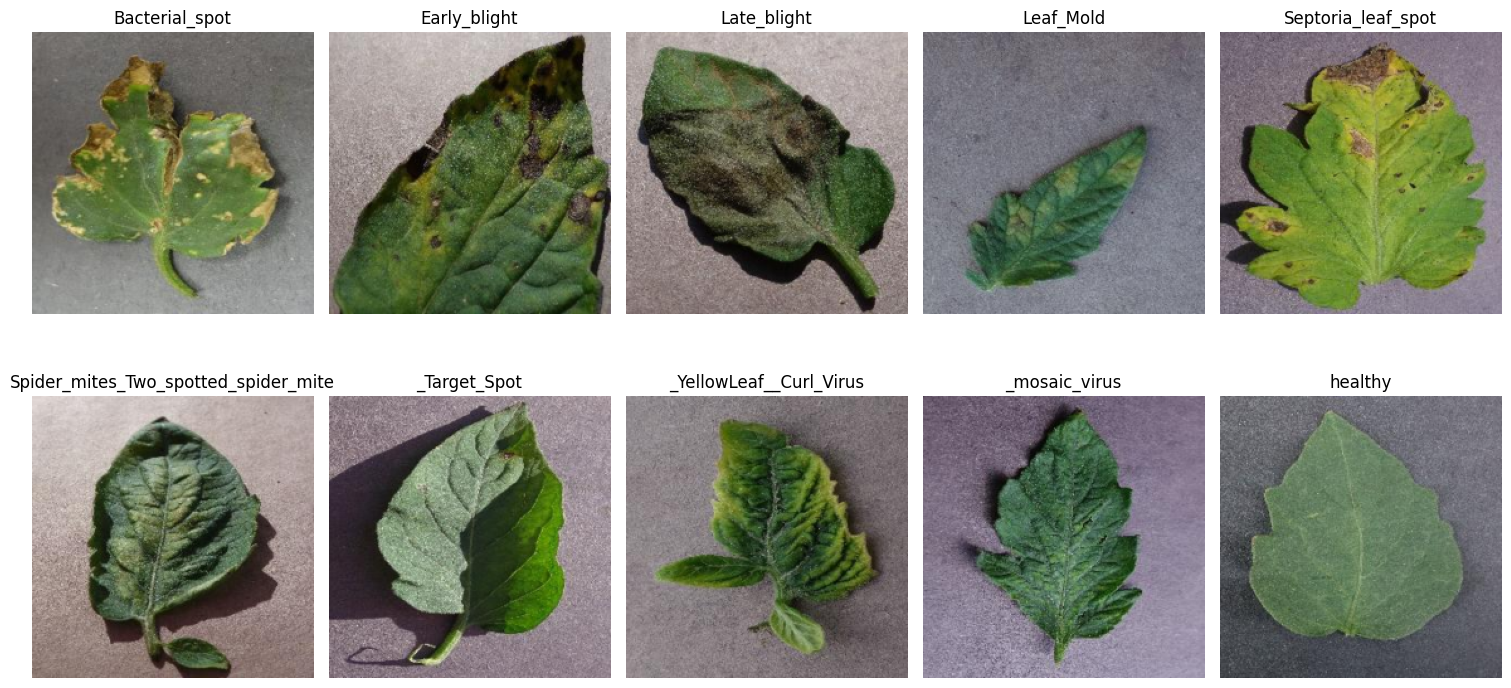

In [5]:
import matplotlib.pyplot as plt

# Temporary pipeline
view_transformation = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

# Only for Visualization
view_dataset = ImageFolder(train_data_local, transform = view_transformation)

class_indices = {}

for idx, (_, class_id) in enumerate(view_dataset.samples):
    if class_id not in class_indices:
        class_indices[class_id] = idx
    if len(class_indices) == len(view_dataset.classes):
        break

plt.figure(figsize = (15, 8))
for class_id, img_idx in class_indices.items():
    image, _ = view_dataset[img_idx]
    class_name = view_dataset.classes[class_id]

    image = image.permute(1, 2, 0).numpy()

    plt.subplot(2, 5, class_id +1)
    plt.imshow(image)
    plt.title(class_name.replace("Tomato_", ""), fontsize = 12)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [6]:
from collections import Counter

labels = train_dataset.targets

count_per_class = Counter(labels)
for i, class_name in enumerate(train_dataset.classes):
    print(f"{class_name:<10} → {count_per_class[i]} samples")
print("="*50)

total_samples = sum(count_per_class.values())
print("Total samples:", total_samples)


Tomato_Bacterial_spot → 1595 samples
Tomato_Early_blight → 750 samples
Tomato_Late_blight → 1433 samples
Tomato_Leaf_Mold → 714 samples
Tomato_Septoria_leaf_spot → 1328 samples
Tomato_Spider_mites_Two_spotted_spider_mite → 1257 samples
Tomato__Target_Spot → 1053 samples
Tomato__Tomato_YellowLeaf__Curl_Virus → 2406 samples
Tomato__Tomato_mosaic_virus → 279 samples
Tomato_healthy → 1193 samples
Total samples: 12008


In [7]:
# Loading and Splitting Data into Train, Test and Validation
from torch.utils.data import random_split
torch.manual_seed(42)
total = len(train_dataset)

train_size = int(0.80 * total)
val_size = total - train_size

train_ds, val_ds = random_split(train_dataset, [train_size, val_size])
len(train_ds), len(val_ds)

(9606, 2402)

In [8]:
from torch.utils.data.dataloader import DataLoader

batch_size = 32
train_loader = DataLoader(train_ds, batch_size, shuffle = True, pin_memory = True, num_workers = 2)
val_loader = DataLoader(val_ds, batch_size, shuffle = False, pin_memory = True, num_workers = 2)
test_loader = DataLoader(test_dataset, batch_size, shuffle = False, pin_memory = True, num_workers = 2)

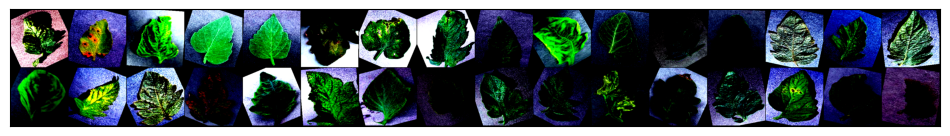

In [9]:
from torchvision.utils import make_grid

def show_batch(dl):
    for image, label in dl:
        fig, ax = plt.subplots(figsize= (12,12))
        ax.set_xticks([])
        ax.set_yticks([])
        ax.imshow(make_grid(image, nrow = 16).permute(1,2,0))
        break

show_batch(train_loader)

In [10]:
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models

# Define Accuracy
def Accuracy(outputs, labels):
    _, preds = torch.max(outputs, dim = 1)
    return torch.tensor(torch.sum(preds == labels).item()/len(preds))

class ImageClassificationBase(nn.Module):

    def training_step(self, batch):
        images, labels = batch
        outputs = self(images)
        loss = F.cross_entropy(outputs, labels)
        return loss

    def validation_step(self, batch):
        images, labels = batch
        outputs = self(images)
        loss = F.cross_entropy(outputs, labels)
        acc = Accuracy(outputs, labels)
        return {f"val_loss": loss.detach(), "val_acc": acc}

    def validation_epoch_end(self, outputs):
        batch_losses = [x['val_loss'] for x in outputs]
        epoch_loss = torch.stack(batch_losses).mean()
        batch_accs = [x['val_acc'] for x in outputs]
        epoch_acc = torch.stack(batch_accs).mean()
        return {'val_loss' : epoch_loss.item(), 'val_acc': epoch_acc.item()}

    def epoch_end(self, epoch, result, is_best = False):
        msg =(
            f"Epoch {epoch} |"
            f"Train Acc: {result['train_acc']:.4f} |"
            f"Train Loss: {result['train_loss']:.4f} |"
            f"Val Acc: {result['val_acc']:.4f} |"
            f"Val Loss {result['val_loss']:.4f} |"
        )
        if is_best:
            msg += " <- Best"
        print(msg)

In [11]:
import torch.nn as nn
import torchvision.models as models

class ResNet(ImageClassificationBase):
    def __init__(self):
        super().__init__()
        self.network = models.resnet18(pretrained = True)
        num_fltrs = self.network.fc.in_features

        # Adding the Dropouts
        self.network.fc = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(num_fltrs, len(train_dataset.classes))
        )

    def forward(self, xb):
        return self.network(xb)

In [12]:
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = ResNet().to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 91.3MB/s]


In [13]:
import torch.optim as optim
opt_func = torch.optim.SGD

optimizer = opt_func(
    model.parameters(),
    lr = 1e-3,
    momentum=0.9,
    weight_decay=1e-4
)

In [14]:
def fit(epochs, model, train_loader, val_laoder, optimizer, device, checkpoint_path="best_model.pth"):
    history = []
    best_val_acc = 0.0 # to validate the best accuracy

    for epoch in range(epochs):

        # ------------------TRAINING------------------
        model.train()
        train_losses = []
        train_correct = 0
        train_total = 0

        for batch in train_loader:
            images , labels = batch
            images = images.to(device)
            labels = labels.to(device)

            # Forward Pass
            outputs = model(images)

            # Loss(same as training_step was doing
            loss = F.cross_entropy(outputs, labels)
            train_losses.append(loss)

            # Train accuracy from the same output
            _, preds = torch.max(outputs, dim=1)
            train_correct += (preds == labels).sum().item()
            train_total += labels.size(0)

            # Backward Pass
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

        train_loss = torch.stack(train_losses).mean().item()
        train_acc = train_correct / train_total

        # --------------------Validation---------------------
        model.eval()
        with torch.no_grad():
            val_outputs = []

            for batch in val_loader:
                images, labels = batch
                images = images.to(device)
                labels = labels.to(device)

                out = model.validation_step((images, labels))
                val_outputs.append(out)

            result = model.validation_epoch_end(val_outputs)
            result['train_loss'] = train_loss
            result['train_acc'] = train_acc

        val_acc = result['val_acc']
        is_best = val_acc > best_val_acc

        model.epoch_end(epoch + 1, result, is_best=is_best)
        history.append(result)

        if is_best:
            best_val_acc = val_acc
            torch.save(
                {
                    "epoch": epoch,
                    "model_state_dict": model.state_dict(),
                    "optimizer_state_dict": optimizer.state_dict(),
                    "val_loss": result['val_loss'],
                    "val_acc": result['val_acc'],
                },
                checkpoint_path,
            )
    return history

In [15]:
epoch = 10
history = fit(epoch, model, train_loader, val_loader, optimizer,
              device, checkpoint_path="best_model.pth")

Epoch 1 |Train Acc: 0.7271 |Train Loss: 0.8193 |Val Acc: 0.9108 |Val Loss 0.2611 | <- Best
Epoch 2 |Train Acc: 0.9107 |Train Loss: 0.2677 |Val Acc: 0.9552 |Val Loss 0.1232 | <- Best
Epoch 3 |Train Acc: 0.9452 |Train Loss: 0.1679 |Val Acc: 0.9593 |Val Loss 0.1168 | <- Best
Epoch 4 |Train Acc: 0.9531 |Train Loss: 0.1387 |Val Acc: 0.9712 |Val Loss 0.0895 | <- Best
Epoch 5 |Train Acc: 0.9656 |Train Loss: 0.1072 |Val Acc: 0.9790 |Val Loss 0.0715 | <- Best
Epoch 6 |Train Acc: 0.9688 |Train Loss: 0.0950 |Val Acc: 0.9778 |Val Loss 0.0560 |
Epoch 7 |Train Acc: 0.9732 |Train Loss: 0.0810 |Val Acc: 0.9840 |Val Loss 0.0530 | <- Best
Epoch 8 |Train Acc: 0.9753 |Train Loss: 0.0744 |Val Acc: 0.9811 |Val Loss 0.0556 |
Epoch 9 |Train Acc: 0.9781 |Train Loss: 0.0663 |Val Acc: 0.9819 |Val Loss 0.0515 |
Epoch 10 |Train Acc: 0.9811 |Train Loss: 0.0588 |Val Acc: 0.9774 |Val Loss 0.0508 |


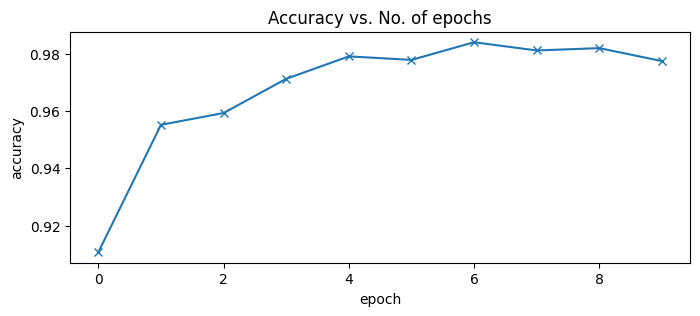

In [16]:
# Plotting the Accuracy
plt.figure(figsize = (8,3))

def plot_accuracy(history):
  accuracies = [x['val_acc'] for x in history]
  plt.plot(accuracies, '-x')
  plt.xlabel('epoch')
  plt.ylabel('accuracy')
  plt.title('Accuracy vs. No. of epochs')

plot_accuracy(history)

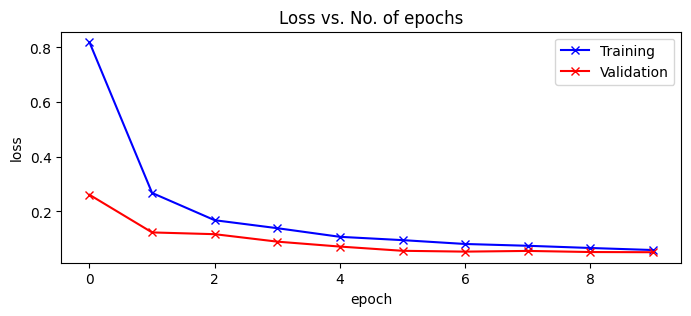

In [17]:
# Plotting the Loss
plt.figure(figsize=(8, 3))


def plot_losses(history):
    train_losses = [x.get('train_loss') for x in history]
    val_losses = [x['val_loss'] for x in history]
    plt.plot(train_losses, '-bx')
    plt.plot(val_losses, '-rx')
    plt.xlabel('epoch')
    plt.ylabel('loss')
    plt.legend(['Training', 'Validation'])
    plt.title('Loss vs. No. of epochs')


plot_losses(history)

In [18]:
checkpoint = torch.load("best_model.pth", map_location=device)
model = ResNet().to(device)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

correct = 0
total = 0

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
print("="*30)
print(f"Test Acc: {correct/total*100:.3f}%")
print("="*30)

Test Acc: 98.035%


In [19]:
# Evaluating model on Accuracy, Precision, Recall, F1-Score, Confusion Matrix
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Accuracy
acc = accuracy_score(all_labels, all_preds)
# Precision
precision = precision_score(all_labels, all_preds, average='weighted')
# Recall
recall = recall_score(all_labels, all_preds, average='weighted')
# F1 - Score
f1 = f1_score(all_labels, all_preds, average='weighted')

print("="*30)

print(f"Accuracy : {acc*100:.3f}%")
print(f"Precision: {precision*100:.3f}")
print(f"Recall   : {recall*100:.3f}")
print(f"F1 Score : {f1*100:.3f}")

print("="*30)

Accuracy : 98.035%
Precision: 98.030
Recall   : 98.035
F1 Score : 98.024


In [20]:
# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
print(cm)

[[543   0   1   0   1   0   0   3   0   0]
 [  3 228   6   0   7   0   5   0   1   0]
 [  0   3 473   0   1   0   0   0   0   1]
 [  1   1   0 234   0   1   0   0   1   0]
 [  2   1   0   2 438   0   0   0   0   0]
 [  0   0   1   0   1 412   5   0   0   0]
 [  4   3   1   1   4   7 330   0   0   1]
 [  0   0   0   0   0   1   0 801   0   0]
 [  0   0   0   2   0   1   0   0  91   0]
 [  1   0   0   0   0   1   3   1   0 392]]


In [22]:
# 1. Ensure the correct library is active
from google import genai
from google.colab import userdata
import torch
from PIL import Image
from IPython.display import Markdown, display

# 2. Re-initialize the client
GOOGLE_API_KEY = userdata.get('API_KEY')
client = genai.Client(api_key=GOOGLE_API_KEY)

# 3. Fixed Insights function using the higher-limit Flash model
def get_disease_insights(predicted_label):
    disease_name = predicted_label.replace("_", " ").replace("  ", " ").strip()

    if "healthy" in disease_name.lower():
        return "🌱 **Status: Healthy**\nThe plant is perfectly healthy! Continue with your standard watering and care routines."

    prompt = f"""
    You are an expert plant pathologist and agricultural advisor.
    A tomato plant has been diagnosed with the following disease: {disease_name}.

    Provide a clear, structured response using the following headings:
    ### Disease Description
    (Provide a brief 2-sentence overview of the disease and its visual symptoms.)

    ### Causes
    (List the primary pathogen, fungus, bacteria, or environmental factors that cause this.)

    ### Preventive Measures
    (List 3 actionable steps to prevent this in the future.)

    ### Treatment Suggestions
    (Provide immediate, practical steps to treat the current infection, including organic and chemical options if applicable.)
    """

    # WE SWITCHED THIS TO GEMINI-2.5-FLASH FOR HIGHER RATE LIMITS
    response = client.models.generate_content(
        model='gemini-2.5-flash',
        contents=prompt
    )
    return response.text

# 4. Fixed Predict function
def predict_and_explain(image_path, model, device, dataset_classes):
    image = Image.open(image_path)
    img_tensor = transformation(image).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        outputs = model(img_tensor)
        _, preds = torch.max(outputs, 1)
        predicted_idx = preds[0].item()

    predicted_label = dataset_classes[predicted_idx]
    print(f"Predicted Class: {predicted_label}\n")
    print("Fetching GenAI Insights...\n")
    print("="*50)

    insights = get_disease_insights(predicted_label)
    display(Markdown(insights))

# 5. Run it!
sample_image = test_dataset.samples[500][0]
predict_and_explain(
    image_path=sample_image,
    model=model,
    device=device,
    dataset_classes=test_dataset.classes
)

Predicted Class: Tomato_Bacterial_spot

Fetching GenAI Insights...



### Disease Description
Tomato Bacterial Spot is a common and destructive bacterial disease affecting tomatoes and peppers worldwide. It is characterized by small, water-soaked lesions on leaves, stems, and fruit that darken and often develop a yellow halo on leaves, leading to significant defoliation and reduced fruit quality.

### Causes
This disease is primarily caused by several species of bacteria belonging to the genus *Xanthomonas*, specifically *Xanthomonas euvesicatoria*, *Xanthomonas vesicatoria*, *Xanthomonas gardneri*, and *Xanthomonas perforans*. These bacteria are typically seed-borne and can survive in infected plant debris, weed hosts, and soil, spreading rapidly through splashing water (rain or irrigation), wind, tools, and human contact, especially in warm, humid conditions.

### Preventive Measures
1.  **Use Certified Disease-Free Seeds and Transplants**: Always start with seeds or seedlings certified free of bacterial spot to avoid introducing the pathogen from the outset.
2.  **Practice Crop Rotation**: Rotate tomatoes and peppers with non-host crops (e.g., corn, beans, cucurbits) for at least 2-3 years to reduce the bacterial inoculum in the soil.
3.  **Optimize Irrigation and Sanitation**: Avoid overhead irrigation to minimize leaf wetness, which favors bacterial spread; use drip irrigation instead. Promptly remove and destroy all plant debris at the end of the season and sterilize tools regularly.

### Treatment Suggestions
Upon diagnosis, immediate action is crucial to manage the infection and prevent further spread:

*   **Immediate Removal of Infected Material**: Carefully remove and destroy all visibly infected leaves, stems, and fruits. Do not compost this material, as it can harbor bacteria. Sanitize pruning tools thoroughly after each cut with a 10% bleach solution or rubbing alcohol.
*   **Copper-based Bactericides**: Apply copper-based bactericides (e.g., copper hydroxide, copper sulfate) as a protective spray. These products create a protective barrier on plant surfaces, inhibiting bacterial entry and growth. Repeat applications are often necessary, following label instructions, especially during periods of warm, wet weather. Copper is an accepted option for both organic and conventional growers.
*   **Cultural Control**: Avoid working with plants when they are wet to prevent manual spread of bacteria. Ensure good air circulation around plants by proper spacing and pruning to help leaves dry quickly. Minimize physical damage to plants, as wounds provide entry points for bacteria.

In [39]:
%%writefile tomato_backend.py
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as transforms
import torchvision.models as models
from google import genai
from google.colab import userdata

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

transformation = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean = [0.485, 0.456, 0.406],
        std = [0.229, 0.224, 0.225]
    )
])

dataset_classes = [
    'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight',
    'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot',
    'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot',
    'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus',
    'Tomato_healthy'
]


class ImageClassificationBase(nn.Module):
    def validation_step(self, batch):
        images, labels = batch
        outputs = self(images)
        loss = F.cross_entropy(outputs, labels)
        acc = Accuracy(outputs, labels)
        return {f"val_loss": loss.detach()}

class ResNet(ImageClassificationBase):
    def __init__(self):
        super().__init__()
        try:
            self.network = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        except AttributeError:
            self.network = models.resnet18(pretrained = True)

        num_fltrs = self.network.fc.in_features

        # Adding the Dropouts
        self.network.fc = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(num_fltrs, len(dataset_classes))
        )

    def forward(self, xb):
        return self.network(xb)

def load_prediction_engine():
    model_instance = ResNet().to(device)

    checkpoint_path = "best_model.pth"
    if os.path.exists(checkpoint_path):
        checkpoint = torch.load(checkpoint_path, map_location = device)
        model_instance.load_state_dict(checkpoint['model_state_dict'])
        print(f"🎯 [Backend] State dict parameters parsed successfully from '{checkpoint_path}'")
    else:
        print(f"⚠️ [Backend] Warning: '{checkpoint_path}' not discovered. Initializing raw baseline model layers.")

    model_instance.eval()
    return model_instance

def get_gemni_client():
    GOOGLE_API_KEY = userdata.get('API_KEY')
    return genai.Client(api_key=GOOGLE_API_KEY)

Overwriting tomato_backend.py


In [40]:
import gradio as gr
from PIL import Image
import torch
import asyncio
import sys
import importlib # Import importlib

import tomato_backend as backend
importlib.reload(backend) # Reload the backend module

# The fix is now applied directly in tomato_backend.py, so this redefinition is no longer strictly necessary
backend.transformation = backend.transformation

model_engine = backend.load_prediction_engine()
gemini_client = backend.get_gemni_client() if hasattr(backend, 'get_gemni_client') else backend.get_gemni_client() # Corrected typo

def plant_diagnostic_app(input_image):
    if input_image is None:
        return "⚠️ Please upload an image profile to begin", ""

    image_tensor = backend.transformation(input_image.convert("RGB")).unsqueeze(0).to(backend.device)

    with torch.no_grad():
        outputs = model_engine(image_tensor)
        _, preds = torch.max(outputs, 1)
        predicted_idx = preds[0].item()

    raw_label = backend.dataset_classes[predicted_idx]
    clean_label = raw_label.replace("_", " ").replace("  ", " ").strip()

    if "healthy" in clean_label.lower():
        return "🩺 Diagnosis: Perfectly Healthy Leaf Profile 🌱", "🌱 **Crop Status: Normal**\n\nThe image sample metrics are sound. Keep up with your standard crop rotation sequences, hydration parameters, and soil balancing routines."

    prompt = f"""
    You are an expert plant pathologist and agricultural advisor.
    A tomato plant leaf sample has been diagnosed with the following pathology: {clean_label}.

    Provide a concise, highly professional agricultural field advisory using exactly these markdown headings:
    ### 🔬 Disease Analysis
    ### ⚠️ Primary Environmental Root Causes
    ### 🛡️ Preventative Field Measures (Max 3 clear points)
    ### 🧪 Prescriptive Treatment Options (Provide organic vs chemical alternatives)
    """

    gr.Info('Consulting Gemini Expert Plant Pathologist....')

    try:
        # ✅ FIXED: Changed .model to .models
        response = gemini_client.models.generate_content(
            model='gemini-2.5-flash',
            contents=prompt
        )
        ai_insights = response.text
    except Exception as e:
        ai_insights = f"⚠️ **Advisory API Connection Timeout:** Unable to extract dynamic crop logs. System Data: {str(e)}"

    return f"🩺 Diagnosis: {clean_label.title()}", ai_insights

agritech_theme = gr.themes.Default(
    primary_hue = 'emerald',
    secondary_hue = 'slate',
    neutral_hue = 'slate'
).set(
    body_background_fill="*neutral_950",
    block_background_fill="*neutral_900",
    block_border_width="1px",
    block_label_text_color="*primary_400",
    button_primary_background_fill="*primary_600",
    button_primary_background_fill_hover="*primary_500"
)
custom_css = """
app-header { text-align: center; margin-bottom: 2rem; padding-bottom: 1rem; border-bottom: 1px solid #334155; }
.output-banner { background: #0f172a !important; border: 1px solid #10b981 !important; border-radius: 8px !important; padding: 15px !important; font-size: 1.15rem !important; font-weight: bold !important;}
.advise-area { font-family: 'Inter', sans-serif; line-height: 1.7; padding: 10px; }
"""

with gr.Blocks(theme = agritech_theme, css = custom_css, title = "Tomato Leaf Health AI Dashboard") as demo:

    with gr.Group(elem_classes = 'app-header'):
        gr.Markdown("# 🍅 Tomato Plant Disease Diagnostics & AI Advisory")
        gr.Markdown('🧪 Dual-engine diagnostic application: Deep Residual Feature Maps (**ResNet-18**) fused with Generative Pathological Advisory (**Gemini 2.5 Flash**).')

    with gr.Row():
        with gr.Column(scale = 1):
            gr.Markdown('### 📤 Crop Sample Ingestion')
            image_input = gr.Image(type="pil", label="Target Leaf Photograph", show_label=True)
            submit_btn = gr.Button("Execute Diagnostic Analysis Scan", variant="primary", size="lg")

        with gr.Column(scale = 1):
            gr.Markdown("### 🔬 Precision System Analysis")
            label_output = gr.Textbox(label="Diagnostic Classification Signature", interactive=False, placeholder="Awaiting pipeline activation...", elem_classes="output-banner")
            markdown_output = gr.Markdown("### 📋 Expert Advisory Field Report\n*Drop an image file profile on the intake panel and trigger the diagnostic scan to map automated prescriptive crop remediation steps directly from Gemini.*", elem_classes="advise-area")

    submit_btn.click(
        fn = plant_diagnostic_app,
        inputs = image_input,
        outputs = [label_output, markdown_output]
    )

# ✅ FIXED: Safe main runtime guarding and Event Loop clean room isolation
if __name__ == "__main__":
    try:
        # Close any lingering event loop from previous ungraceful exits
        loop = asyncio.get_event_loop()
        if loop.is_running():
            loop.stop()
    except RuntimeError:
        pass

    # Create a completely fresh execution context loop
    asyncio.set_event_loop(asyncio.new_event_loop())

    # Run the dashboard securely
    demo.launch(debug=True)

🎯 [Backend] State dict parameters parsed successfully from 'best_model.pth'


/tmp/ipykernel_4070/3433851222.py:77: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(theme = agritech_theme, css = custom_css, title = "Tomato Leaf Health AI Dashboard") as demo:
/tmp/ipykernel_4070/3433851222.py:77: DeprecationWarning: The 'css' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'css' to Blocks.launch() instead.
  with gr.Blocks(theme = agritech_theme, css = custom_css, title = "Tomato Leaf Health AI Dashboard") as demo:


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://8adef4bedd06ac9ff6.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://8adef4bedd06ac9ff6.gradio.live
